### 馬達論文研究
### 第三步 模型建立
### 馬達C 8000RPM 當作基準模型
### 8000 RPM 可能是最適合巡航的轉速，因為它提供足夠的推力又不會過度耗電。
### CNN_Res

In [25]:
# --- logging bootstrap (auto-added) ---
import importlib
from scripts import logger as _logger_mod
_logger_mod = importlib.reload(_logger_mod)
save_plot = _logger_mod.save_plot
setup_logger = _logger_mod.setup_logger
tee_std_to_file = _logger_mod.tee_std_to_file

LOG, RUN_PATHS = setup_logger('notebook', console=False)
_tee_ctx = tee_std_to_file(RUN_PATHS.log_file)
_tee_ctx.__enter__()
import atexit
atexit.register(_tee_ctx.__exit__, None, None, None)

# Ensure TensorFlow releases GPU/graph resources on exit
try:
    import tensorflow as tf
    atexit.register(tf.keras.backend.clear_session)
except Exception:
    pass

# Auto-save matplotlib figures on plt.show()
try:
    import matplotlib.pyplot as plt
    if not getattr(plt, '_ancestor_save_plot_patched', False):
        plt._ancestor_save_plot_patched = True
        _orig_show = plt.show
        import time
        plt._ancestor_show_in_progress = False
        plt._ancestor_last_save_ts = 0.0

        def _show_and_save(*args, **kwargs):
            if getattr(plt, '_ancestor_show_in_progress', False):
                return _orig_show(*args, **kwargs)
            now = time.monotonic()
            if now - float(getattr(plt, '_ancestor_last_save_ts', 0.0)) < 0.5:
                return _orig_show(*args, **kwargs)
            plt._ancestor_show_in_progress = True
            try:
                save_plot(plt, LOG, RUN_PATHS)
            except Exception:
                pass
            try:
                return _orig_show(*args, **kwargs)
            finally:
                plt._ancestor_last_save_ts = time.monotonic()
                try:
                    plt.close(plt.gcf())
                except Exception:
                    pass
                plt._ancestor_show_in_progress = False

        plt.show = _show_and_save
except Exception:
    pass
# --- end logging bootstrap ---


In [26]:
# 匯入所需函式庫
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, MinMaxScaler
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from scripts.gpu_utils import device_scope, DEVICE
warnings.filterwarnings("ignore")


In [27]:
# 資料準備與處理
def load_and_preprocess_data(base_dir, screws_list):
    datasets = []
    for screws in screws_list:
        file_path = os.path.join(base_dir, 'T1', '8000rpm', screws, 'T1_Group_feature_data.csv')
        if os.path.exists(file_path):
            dataset = pd.read_csv(file_path)
            dataset['screws'] = screws
            datasets.append(dataset)
        else:
            print(f"檔案未找到: {file_path}")
    return datasets

In [28]:
# 加載資料
rootDir = os.getcwd()
myfeatureDirectory = os.path.join(rootDir, 'data', 'Step-1', 'myfeature')

screws_list = ['8screws', '1screws', '2screws', '3screws', '4screws']
datasets_T1 = load_and_preprocess_data(myfeatureDirectory, screws_list)

In [29]:
# 合併資料
combined_data = pd.concat(datasets_T1, ignore_index=True)

In [30]:
# **手動定義標籤順序**
desired_order = ['8screws', '1screws', '2screws', '3screws', '4screws']
label_mapping = {screw: idx for idx, screw in enumerate(desired_order)}
combined_data['screws'] = combined_data['screws'].map(label_mapping)

In [32]:
# 確認標籤映射是否正確
print("自訂 Label Mapping:")
for label, num in label_mapping.items():
    print(f"{label}: {num}")

自訂 Label Mapping:
8screws: 0
1screws: 1
2screws: 2
3screws: 3
4screws: 4


In [33]:
# 資料分割
X = combined_data.drop(['screws'], axis=1).values
y_screws = combined_data['screws'].values

In [34]:
# 劃分訓練與測試集
X_train, X_test, y_train_screws, y_test_screws = train_test_split(
    X, y_screws, test_size=0.2, random_state=42, stratify=y_screws
)

In [35]:
# 若你在標準化之前尚未保存原始資料，可以先建立一個副本
X_train_original = X_train.copy()

In [36]:
# 標準化特徵
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

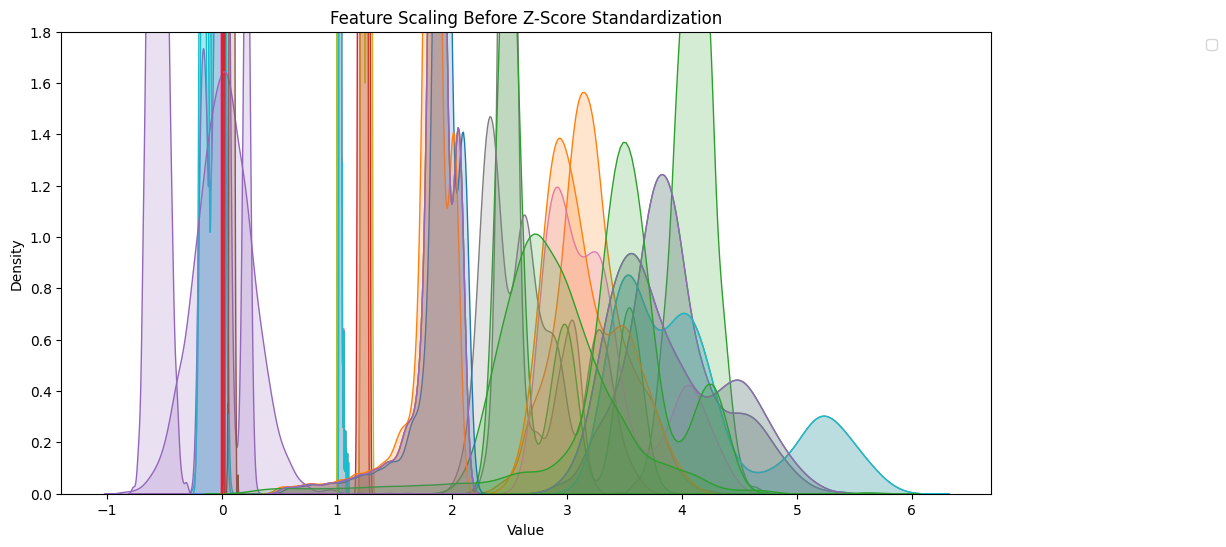

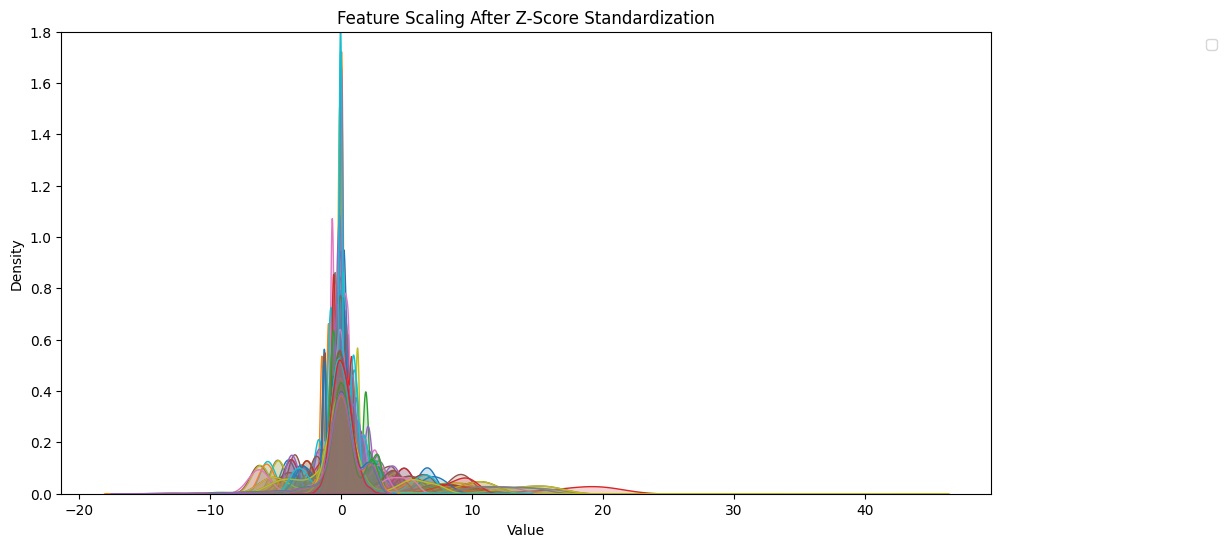

In [37]:
# ======================
# Plot - Before Standardization
# ======================
plt.figure(figsize=(12, 6))
for i in range(X_train_original.shape[1]):
    sns.kdeplot(
        X_train_original[:, i], 
        # label=f"Feature {i}", 
        fill=True, 
        alpha=0.2
    )
plt.title("Feature Scaling Before Z-Score Standardization")
plt.xlabel("Value")
plt.ylabel("Density")
plt.ylim(0, 1.8)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

# ======================
# Plot - After Standardization
# ======================
plt.figure(figsize=(12, 6))
for i in range(X_train.shape[1]):
    sns.kdeplot(
        X_train[:, i], 
        # label=f"Feature {i}", 
        fill=True, 
        alpha=0.2
    )
plt.title("Feature Scaling After Z-Score Standardization")
plt.xlabel("Value")
plt.ylabel("Density")
plt.ylim(0, 1.8)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

In [38]:
# ResNet 殘差模塊
def res_block(X_input, filters, stride=1):
    shortcut = X_input

    # 主分支 - Conv1
    X = Conv1D(filters, kernel_size=3, strides=stride, padding='same')(X_input)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)

    # 主分支 - Conv2
    X = Conv1D(filters, kernel_size=3, strides=1, padding='same')(X)
    X = BatchNormalization()(X)

    # 如果維度不一致則使用 Conv1D 處理 shortcut
    if X_input.shape[-1] != filters or stride != 1:
        shortcut = Conv1D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # 殘差連接
    X = Add()([X, shortcut])
    X = Activation('relu')(X)
    return X

In [39]:
# 建立 ResNet 模型
def build_resnet_model(input_shape, num_classes):
    # 輸入層
    X_input = Input(shape=input_shape)

    # 初始卷積層（第 1 層）
    X = Conv1D(32, kernel_size=7, strides=2, padding='same')(X_input)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)
    X = MaxPooling1D(pool_size=3, strides=2, padding='same')(X)

    # conv2_x: 2 個 basic blocks（第 2~5 層）
    X = res_block(X, filters=32, stride=1)
    X = res_block(X, filters=32, stride=1)

    # conv3_x: 2 個 basic blocks（第 6~9 層）
    X = res_block(X, filters=32, stride=2)
    X = res_block(X, filters=32, stride=1)

    # conv4_x: 2 個 basic blocks（第 10~13 層）
    X = res_block(X, filters=64, stride=2)
    X = res_block(X, filters=64, stride=1)

    # conv5_x: 2 個 basic blocks（第 14~17 層）
    X = res_block(X, filters=128, stride=2)
    X = res_block(X, filters=128, stride=1)

    # GlobalAveragePooling + Dense（第 18 層）
    X = GlobalAveragePooling1D()(X)
    output = Dense(num_classes, activation='softmax', name="Screw_Number_Output")(X)

    # 定義模型
    model = Model(inputs=X_input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [40]:
# 模型參數
num_classes = len(np.unique(y_train_screws))

In [41]:
print(f"[Training] Device: {DEVICE}")
with device_scope():
    # 建立模型
    resnet_model = build_resnet_model((X_train.shape[1], 1), num_classes)
    
    # 訓練模型
    history = resnet_model.fit(
        X_train.reshape(X_train.shape[0], X_train.shape[1], 1), y_train_screws,
        validation_data=(
            X_test.reshape(X_test.shape[0], X_test.shape[1], 1), y_test_screws
        ),
        epochs=100,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )

[Training] Device: /GPU:0
Epoch 1/100


I0000 00:00:1778140462.236091   75721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73060__.158


70/75 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7401 - loss: 0.7193

I0000 00:00:1778140469.500344   75721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_73060__.158


75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9011 - loss: 0.3583 - val_accuracy: 0.4185 - val_loss: 1.1182
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9941 - loss: 0.0354 - val_accuracy: 0.9597 - val_loss: 0.4743
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 0.0447
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9983 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9983 - loss: 0.0066 - val_accuracy: 1.0000 - val_loss: 6.5305e-04
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_

In [43]:
# 模型架構
resnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 105, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 53, 32)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 53, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 53, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 27, 32)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 27, 32)    │      3,104 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 27, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 27, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 27, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 27, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 27, 32)    │      3,104 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 27, 32)    │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 27, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 769,329 (2.93 MB)

 Trainable params: 255,589 (998.39 KB)

 Non-trainable params: 2,560 (10.00 KB)

 Optimizer params: 511,180 (1.95 MB)

In [44]:
# 評估模型
results = resnet_model.evaluate(
    X_test.reshape(X_test.shape[0], X_test.shape[1], 1),
    y_test_screws
)
print(f"Loss: {results[0]:.4f}, Accuracy: {results[1]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 7.5900e-06
Loss: 0.0000, Accuracy: 1.0000


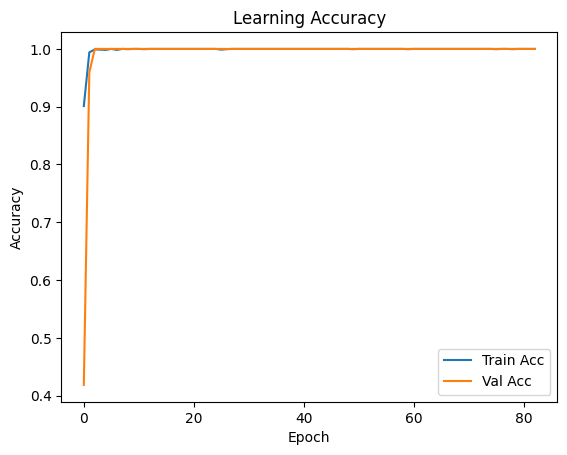

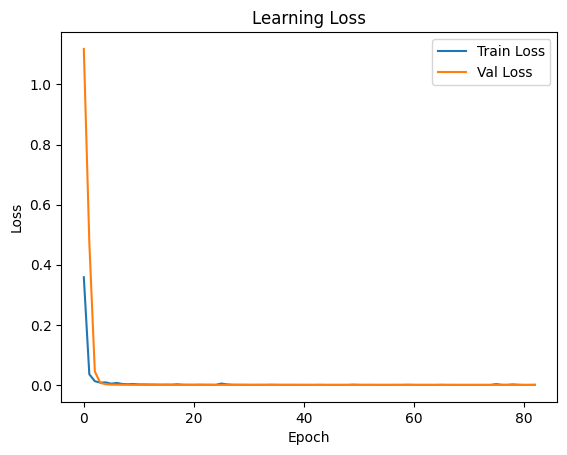

In [45]:
# 繪製學習曲線
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


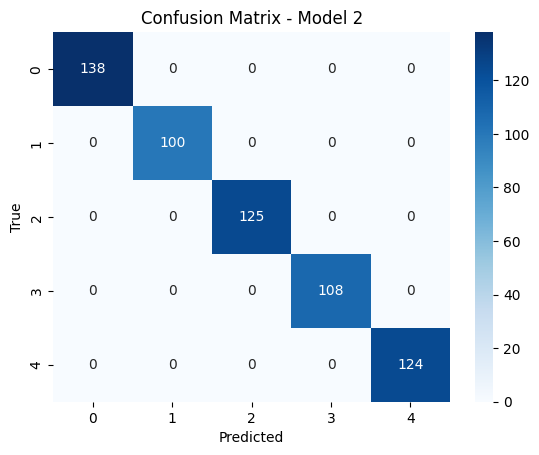

In [46]:
# 混淆矩陣繪製
def plot_confusion_matrix(y_true, y_pred, class_labels, title):
    """
    繪製混淆矩陣，顯示數字映射標籤
    """
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 預測並繪製混淆矩陣
y_pred_screw = resnet_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1], 1)).argmax(axis=1)
plot_confusion_matrix(y_test_screws, y_pred_screw, list(range(len(desired_order))), "Confusion Matrix - Model 2")

In [47]:
# 儲存模型
resnet_model.save(os.path.join(rootDir, 'data', 'Step-1', 'model', 'ResNet_C8000.keras'))